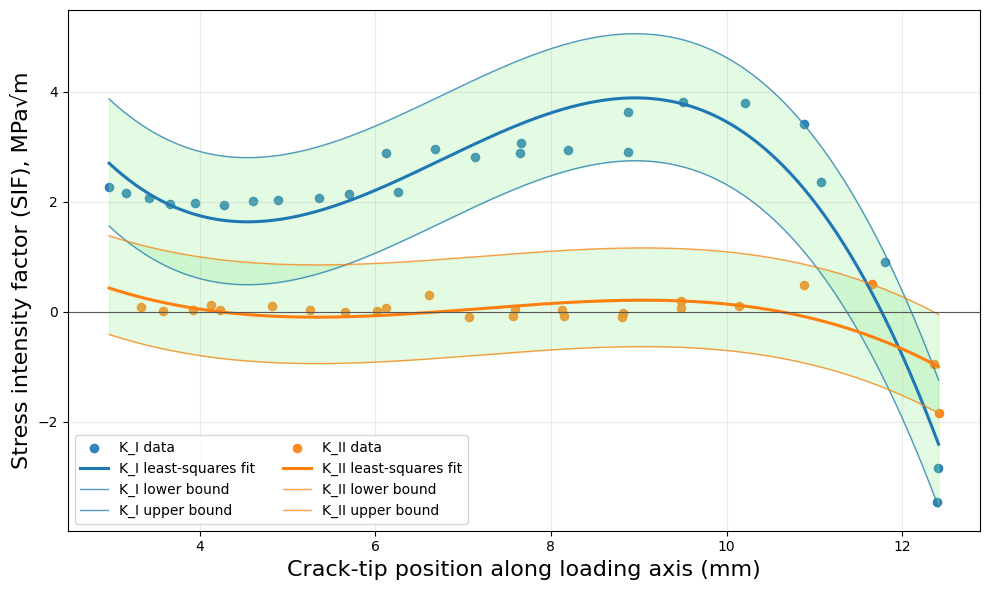

In [5]:
## Least squares fits to K_I and K_II data in compression experiments

import numpy as np
import matplotlib.pyplot as plt

# Digitized data: y-position vs SIF
ki = np.array([
    [2.96997115830967, 2.26123418082751],
    [3.16265495749845, 2.16184830336284],
    [3.42439900461923, 2.06238632645141],
    [3.65855700229058, 1.96846438926389],
    [3.94864809332835, 1.97365437153272],
    [4.27987093533829, 1.93472189457183],
    [4.61185477181580, 2.00598141651510],
    [4.88824796243731, 2.02771541850891],
    [5.35812399643854, 2.06576514188742],
    [5.70391988250245, 2.13700944394134],
    [6.25674431346883, 2.18598704787416],
    [6.12349418219729, 2.89136803975435],
    [6.67647081205718, 2.96238404346800],
    [7.13124110587715, 2.81312258859878],
    [7.64285768642461, 2.89520345187091],
    [7.65784927743574, 3.06598583028301],
    [8.19564406766762, 2.93867145585852],
    [8.87224424878430, 2.91037768155426],
    [8.87722876254689, 3.63213527437656],
    [9.49998858508298, 3.80775757760241],
    [10.2042889648192, 3.79045256340986],
    [10.8784539636397, 3.40954439261227],
    [11.0784433097171, 2.36800170462761],
    [11.8003607113776, 0.901641465066549],
    [12.4098031307312, -2.85109621253053],
    [12.3917675618498, -3.46264658655932],
])

kii = np.array([
    [3.32926606831747, 0.0832458032743578],
    [3.58270489895781, 0.0208719880749469],
    [3.92133615945356, 0.0387847263716013],
    [4.13354675992024, 0.130247872547848],
    [4.23163283918159, 0.0388539118074381],
    [4.82452057637757, 0.110335046197003],
    [5.26117502028391, 0.0279351921153762],
    [5.65586220777015, -0.00542162233557428],
    [6.12176322228022, 0.0593422351927445],
    [6.02276515318284, 0.0214160371840272],
    [6.61709949494632, 0.298025699244621],
    [7.58851018598302, 0.0440616882504263],
    [7.06567270257181, -0.0942934594604793],
    [7.57360386935274, -0.0696540099249649],
    [8.12435138653902, 0.0263439270911302],
    [8.15183687332146, -0.0762140471593089],
    [8.81513651544407, -0.0203247941733281],
    [8.81463334863798, -0.0916738472762952],
    [9.47860912115627, 0.0600906958167973],
    [9.47961545476844, 0.202788802022731],
    [10.1417986955400, 0.100372343436504],
    [10.8779789047316, 0.490726006805331],
    [11.6537677759398, 0.497587944123327],
    [12.3629027693043, -0.947069996792312],
    [12.4129993144352, -1.84337989722818],
])

def polyfit_with_bounds(x, y, degree=3):
    coeff = np.polyfit(x, y, degree)
    model = np.poly1d(coeff)
    y_fit = model(x)
    residual = y - y_fit
    # Shifted fit envelope so all scatter points are bounded.
    lower_shift = residual.min()
    upper_shift = residual.max()
    return model, lower_shift, upper_shift

ki_x, ki_y = ki[:, 0], ki[:, 1]
kii_x, kii_y = kii[:, 0], kii[:, 1]

ki_model, ki_low, ki_up = polyfit_with_bounds(ki_x, ki_y, degree=3)
kii_model, kii_low, kii_up = polyfit_with_bounds(kii_x, kii_y, degree=3)

x_min = min(ki_x.min(), kii_x.min())
x_max = max(ki_x.max(), kii_x.max())
x_plot = np.linspace(x_min, x_max, 500)

ki_fit = ki_model(x_plot)
ki_lower = ki_fit + ki_low
ki_upper = ki_fit + ki_up

kii_fit = kii_model(x_plot)
kii_lower = kii_fit + kii_low
kii_upper = kii_fit + kii_up

plt.figure(figsize=(10, 6))

# K_I
plt.scatter(ki_x, ki_y, s=35, color='tab:blue', alpha=0.9, label='K_I data')
plt.plot(x_plot, ki_fit, color='tab:blue', lw=2.2, label='K_I least-squares fit')
plt.plot(x_plot, ki_lower, color='tab:blue', lw=1.0, alpha=0.75, label='K_I lower bound')
plt.plot(x_plot, ki_upper, color='tab:blue', lw=1.0, alpha=0.75, label='K_I upper bound')
plt.fill_between(x_plot, ki_lower, ki_upper, color='lightgreen', alpha=0.25)

# K_II
plt.scatter(kii_x, kii_y, s=35, color='tab:orange', alpha=0.9, label='K_II data')
plt.plot(x_plot, kii_fit, color='tab:orange', lw=2.2, label='K_II least-squares fit')
plt.plot(x_plot, kii_lower, color='tab:orange', lw=1.0, alpha=0.75, label='K_II lower bound')
plt.plot(x_plot, kii_upper, color='tab:orange', lw=1.0, alpha=0.75, label='K_II upper bound')
plt.fill_between(x_plot, kii_lower, kii_upper, color='lightgreen', alpha=0.25)

plt.axhline(0.0, color='0.35', lw=0.8)
plt.xlabel('Crack-tip position along loading axis (mm)', fontsize=16)
plt.ylabel('Stress intensity factor (SIF), MPa√m', fontsize=16)
# plt.title()
plt.grid(alpha=0.25)
plt.legend(ncol=2, frameon=True)
plt.tight_layout()
plt.show()
